## 1. Setup & Data Loading

Import libraries, load the raw transactions CSV, and define which columns are categorical, numerical, and the label. We drop PII-like identifiers (`transaction_id`, `user_id`) so the model trains only on behavioural signals.

In [206]:
fileURL = 'transactions.csv'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

transactions_df = pd.read_csv(fileURL)

print ("Shape :", transactions_df.shape)

transactions_df_anonymized = transactions_df.drop(columns=["transaction_id", "user_id" ])

categorical_cols = ['transaction_type', 'merchant_category', 'country']
numerical_cols = ['amount',  'device_risk_score', 'ip_risk_score']
ordered_cols = "hour"
label_col = "is_fraud"

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

transactions_df_anonymized.head()


Shape : (10000, 10)
Categorical Columns: ['transaction_type', 'merchant_category', 'country']
Numerical Columns: ['amount', 'device_risk_score', 'ip_risk_score']


,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


## 2. Summary Statistics

Get a statistical overview of every numerical column (mean, std, quartiles). This helps spot scale differences between features (e.g. `amount` vs. `device_risk_score`), detect potential outliers, and confirm the class imbalance — `is_fraud` mean of 0.05 indicates only 5% of transactions are fraudulent.

In [207]:
transactions_df_anonymized.describe()

,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,178.142763,14.247100,0.183773,0.184669,0.050000
std,531.647950,5.347383,0.177381,0.175772,0.217956
min,1.000000,0.000000,0.000030,0.000009,0.000000
25%,65.084753,10.000000,0.075721,0.077762,0.000000
50%,101.686510,14.000000,0.156583,0.158290,0.000000
75%,138.280872,19.000000,0.234939,0.236968,0.000000
max,11628.213881,23.000000,0.998737,0.999603,1.000000


## 3. Train / Test Split

Split the dataset 80/20 into training and test sets. `stratify=is_fraud` preserves the 5% fraud ratio in both splits, ensuring the test set gives a representative evaluation rather than accidentally over- or under-representing fraud cases.

In [208]:
from sklearn.model_selection import train_test_split

transactions_df_train, transactions_df_test = train_test_split(transactions_df_anonymized, test_size=0.2, random_state=42, stratify=transactions_df_anonymized["is_fraud"])

## 4. Numerical Feature Distributions

Plot histograms of all numerical columns to understand their shape and spread. A heavily right-skewed `amount` column (mean 178, max 11,628) signals the need for scaling later. Risk scores clustered near 0 with a high-value tail are a classic pattern in fraud datasets.

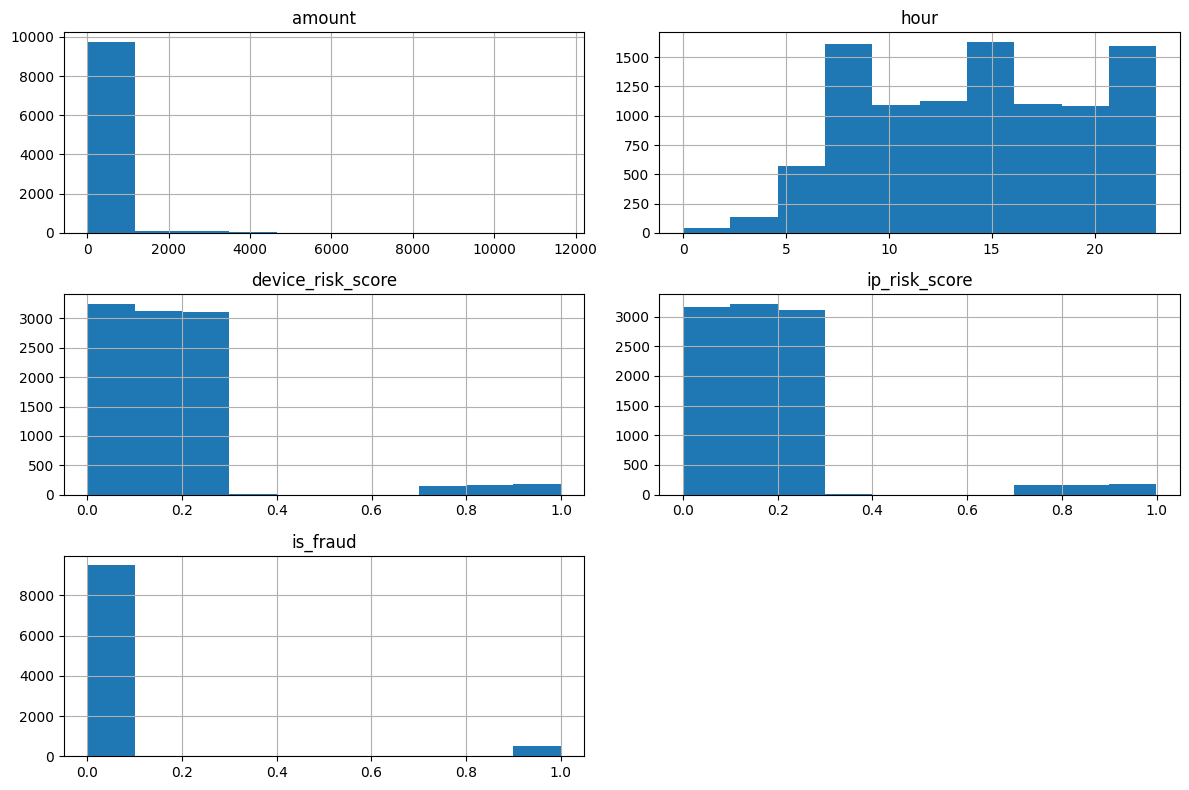

In [209]:
transactions_df_anonymized.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## 5. Data Quality — Null Check

Verify there are no missing values in the training set before modelling. Missing values in risk scores or transaction type would silently corrupt downstream encoding and scaling steps.

In [210]:
transactions_df_train.isnull().sum()


amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

## 6. Separate Features and Labels

Detach the `is_fraud` target column from the feature matrix for both splits. We also print training label counts to confirm the stratified split maintained the ~5% fraud rate (400 fraud vs. 7,600 legitimate).

In [211]:
transactions_df_train_labels = transactions_df_train["is_fraud"]
transactions_df_train_features = transactions_df_train.drop(columns=["is_fraud"])

transactions_df_test_labels = transactions_df_test["is_fraud"]
transactions_df_test_features = transactions_df_test.drop(columns=["is_fraud"])

print("Training Labels Count:")
print(transactions_df_train_labels.value_counts())


transactions_df_train.shape, transactions_df_test.shape, transactions_df_train_labels.shape, transactions_df_test_labels.shape

Training Labels Count:
is_fraud
0    7600
1     400
Name: count, dtype: int64


((8000, 8), (2000, 8), (8000,), (2000,))

## 7. Outlier Removal — Isolation Forest

Use an unsupervised Isolation Forest on the numerical columns to flag and remove anomalous rows from the training set. `contamination=0.01` marks ~1% as outliers. We only clean training data — the test set must stay untouched to give an honest, unbiased evaluation.

In [212]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

isolation_forest.fit(transactions_df_train[numerical_cols])

train_predictions = isolation_forest.predict(transactions_df_train[numerical_cols])

print("Outliers in training data:", 10000 - train_predictions.sum())

transactions_df_train = transactions_df_train[train_predictions == 1]
transactions_df_train_labels = transactions_df_train_labels[train_predictions == 1]

transactions_df_train.shape

Outliers in training data: 2160


(7920, 8)

## 8. Categorical Feature Distributions

Bar charts for each categorical column reveal which transaction types, merchant categories, and countries dominate the training data. Heavily skewed categories can bias the model — rare categories may be under-learned, while dominant ones may over-influence decision boundaries.

In [ ]:
# Visualize the distribution of each categorical feature in the training set.
# This helps identify class imbalance within categories and spot dominant
# transaction types, merchant sectors, or geographies — all potential
# signals for fraud detection.

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    transactions_df_train[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Categorical Feature Distributions — Interpretation

**`transaction_type`**
Expect ATM, Online, POS, and QR to appear. ATM and Online transactions historically carry higher fraud risk because they are card-not-present or high-value cash events. If ATM is over-represented relative to its share in legitimate transactions, it warrants closer attention during modelling.

**`merchant_category`**
Categories like Travel and Electronics tend to have higher average transaction amounts, which correlates with fraud. A long tail of low-count categories (e.g. Grocery) being rare in the training set may cause the model to under-learn fraud patterns there — worth monitoring in evaluation.

**`country`**
The dataset spans multiple countries (TR, US, FR, NG, UK, others). Significant skew toward one country is expected if most customers are from that region, but an unusually high share of transactions from high-risk geographies (e.g. NG) relative to legitimate volume is a meaningful fraud signal.

**General note:** These plots are drawn from the *training* set after Isolation Forest outlier removal (7,920 samples, 5% fraud rate). Bars reflect counts, not fraud rates — a dominant bar does not imply high fraud risk by itself; cross-tabulating with `is_fraud` would give a cleaner signal.

## 9. Ordinal Feature Distribution — Hour of Day

Plot transaction counts sorted by hour (0–23) to understand temporal patterns. Fraud often clusters at unusual hours (e.g. late night). Sorting by index rather than frequency preserves the natural time ordering, making any temporal concentration visible at a glance.

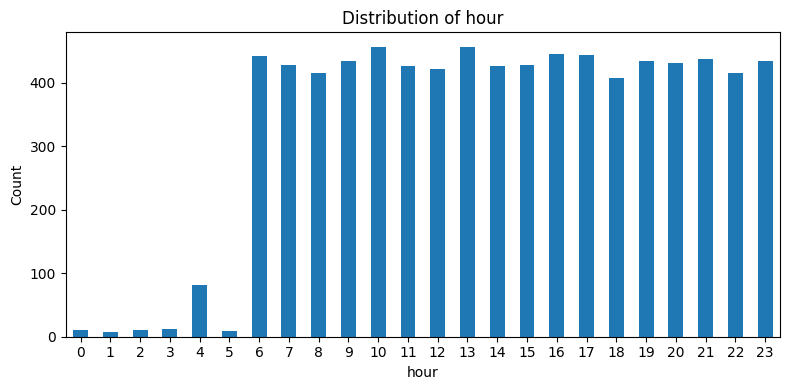

In [214]:
# plot bar chart for all ordinal column - hour

plt.figure(figsize=(8, 4))
transactions_df_train[ordered_cols].value_counts().sort_index().plot(kind='bar')
plt.title(f"Distribution of {ordered_cols}")
plt.xlabel(ordered_cols)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
 

## 10. Cyclical Encoding of Hour

Hour is a circular feature — hour 23 is adjacent to hour 0, but a raw integer would make them appear maximally distant to the model. Encoding as sine and cosine components preserves this cyclical relationship. The original `hour` column is dropped after encoding.

In [215]:
max_hour = 24
transactions_df_train['hour_sin'] = np.sin(2 * np.pi * transactions_df_train['hour'] / max_hour)
transactions_df_train['hour_cos'] = np.cos(2 * np.pi * transactions_df_train['hour'] / max_hour)

transactions_df_test['hour_sin'] = np.sin(2 * np.pi * transactions_df_test['hour'] / max_hour)
transactions_df_test['hour_cos'] = np.cos(2 * np.pi * transactions_df_test['hour'] / max_hour) 
transactions_df_train = transactions_df_train.drop(columns=["hour"])
transactions_df_test = transactions_df_test.drop(columns=["hour"])
numerical_cols.append("hour_sin")
numerical_cols.append("hour_cos")

print(transactions_df_train.shape)
print(transactions_df_test.shape)


(7920, 9)
(2000, 9)


## 11. One-Hot Encoding of Categorical Features

Convert categorical columns into binary dummy variables so the model can split on them. `drop_first=True` removes one dummy per group to avoid perfect multicollinearity. Encoding is applied independently to train and test — fitting only on train — to prevent data leakage.

In [216]:

transactions_df_train_cat = pd.get_dummies(transactions_df_train[categorical_cols], drop_first=True)
transactions_df_train_num = transactions_df_train[numerical_cols]
transactions_df_train = pd.concat([transactions_df_train_num, transactions_df_train_cat], axis=1)
print(transactions_df_train.shape)

transactions_df_test_cat = pd.get_dummies(transactions_df_test[categorical_cols], drop_first=True)
transactions_df_test_num = transactions_df_test[numerical_cols]
transactions_df_test = pd.concat([transactions_df_test_num, transactions_df_test_cat], axis=1)
print(transactions_df_test.shape)


(7920, 17)
(2000, 17)


## 12. Inspect Encoded Feature Matrix

Preview the first few rows of the fully encoded training set to confirm that one-hot columns look correct and no unexpected nulls were introduced during concatenation of numerical and categorical sub-frames.

In [217]:
transactions_df_train.head()

,amount,device_risk_score,ip_risk_score,hour_sin,hour_cos,transaction_type_Online,transaction_type_POS,transaction_type_QR,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel,country_FR,country_NG,country_TR,country_UK,country_US
1771,97.887042,0.073841,0.153680,-0.500000,0.866025,False,True,False,False,False,False,True,False,False,False,False,False
5149,94.161800,0.250203,0.103801,0.258819,-0.965926,False,False,False,False,True,False,False,False,False,True,False,False
456,80.783739,0.076352,0.261951,0.866025,-0.500000,False,True,False,False,False,False,False,False,False,True,False,False
1343,51.411597,0.127681,0.028990,-0.707107,-0.707107,False,False,True,False,False,False,False,False,False,False,False,False
5957,121.744317,0.205196,0.234584,0.707107,-0.707107,False,True,False,True,False,False,False,False,False,True,False,False


## 13. Feature Scaling — Standardise Amount

`amount` has a wide range (1–11,628) compared to the bounded risk scores (0–1). We apply `StandardScaler` (zero mean, unit variance), fitting on training data only and transforming both splits. Fitting on test data would leak test-set statistics into the scaler.

In [218]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
transactions_df_train["amount"] = scaler.fit_transform(transactions_df_train["amount"].values.reshape(-1, 1))
transactions_df_test["amount"] = scaler.transform(transactions_df_test["amount"].values.reshape(-1, 1))
transactions_df_train.head()

print(transactions_df_train.shape)
print(transactions_df_test.shape)


(7920, 17)
(2000, 17)


## 14. Final Shape Check

Sanity check that train (7,920 × 17) and test (2,000 × 17) shapes are consistent after all preprocessing steps. Encoding, scaling, and outlier removal should not have accidentally dropped or duplicated columns.

In [219]:
print(transactions_df_train.shape)
print(transactions_df_test.shape)


(7920, 17)
(2000, 17)


## 15. Model Training & Evaluation — Random Forest

Train a Random Forest (100 trees) on the preprocessed training set. We report per-class precision, recall, and F1 on both train and test, print the confusion matrix, and run 5-fold cross-validation F1 to verify the perfect test score generalises and is not a lucky split artefact.

In [220]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(transactions_df_train, transactions_df_train_labels)
train_predictions = rf_classifier.predict(transactions_df_train)
print("Training Classification Report:")
print(classification_report(transactions_df_train_labels, train_predictions))

test_predictions = rf_classifier.predict(transactions_df_test)
print("Test Classification Report:")
print(classification_report(transactions_df_test_labels, test_predictions))

print("Confusion Matrix:")
print(confusion_matrix(transactions_df_test_labels, test_predictions))


from sklearn.model_selection import cross_val_score
cross_val_scores = cross_val_score(rf_classifier, transactions_df_train, transactions_df_train_labels, cv=5, scoring='f1')
print("Cross-validation F1 scores:", cross_val_scores)
print("Average F1 score:", cross_val_scores.mean())




Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7600
           1       1.00      1.00      1.00       320

    accuracy                           1.00      7920
   macro avg       1.00      1.00      1.00      7920
weighted avg       1.00      1.00      1.00      7920

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
[[1900    0]
 [   0  100]]
Cross-validation F1 scores: [1. 1. 1. 1. 1.]
Average F1 score: 1.0
